In [2]:
# ================================================================
# 1. Installing Libraries
# ================================================================

print("\n===== Installing Libraries =====\n")

!pip install pandas
!pip install numpy
!pip install openpyxl

print("\n===== All libraries installed successfully  =====\n")


===== Installing Libraries =====


===== All libraries installed successfully  =====




===== Importing Required Libraries =====

===== LIBRARY VERSIONS =====

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
tqdm: 4.67.3
re: built-in (no version)

===== DATASET PREPARATION =====

===== Dataset Loading, Cleaning and Preparation for BFSI Tasks =====

Download completed
Extracting dataset...
Extraction completed
File exists: True
Collected: 24715
Collected: 49460
Collected: 74572
Collected: 99280
Collected: 124345
Final Shape: (100000, 5)

===== DATASET INFORMATION =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 100000 non-null  object
 1   Product                       100000 non-null  object
 2   Issue                         100000 non-null  object
 3   Consumer complaint narrative  100000 non-null  object
 4   Company response to consumer  99999 non-null   o

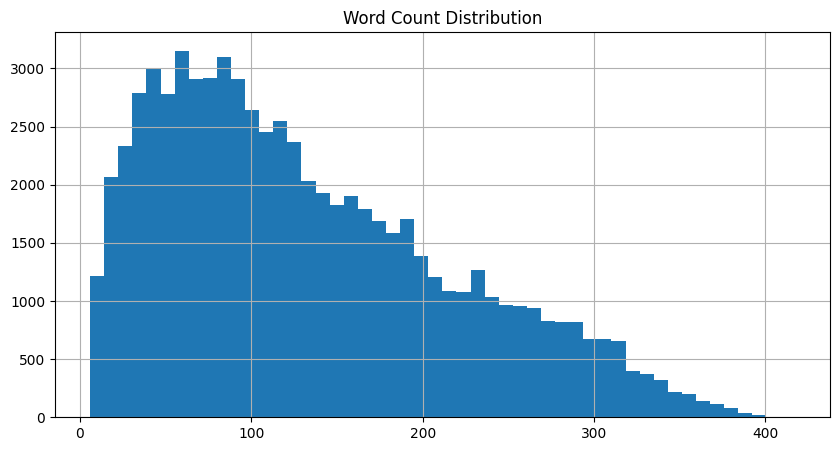


===== PRODUCT DISTRIBUTION =====



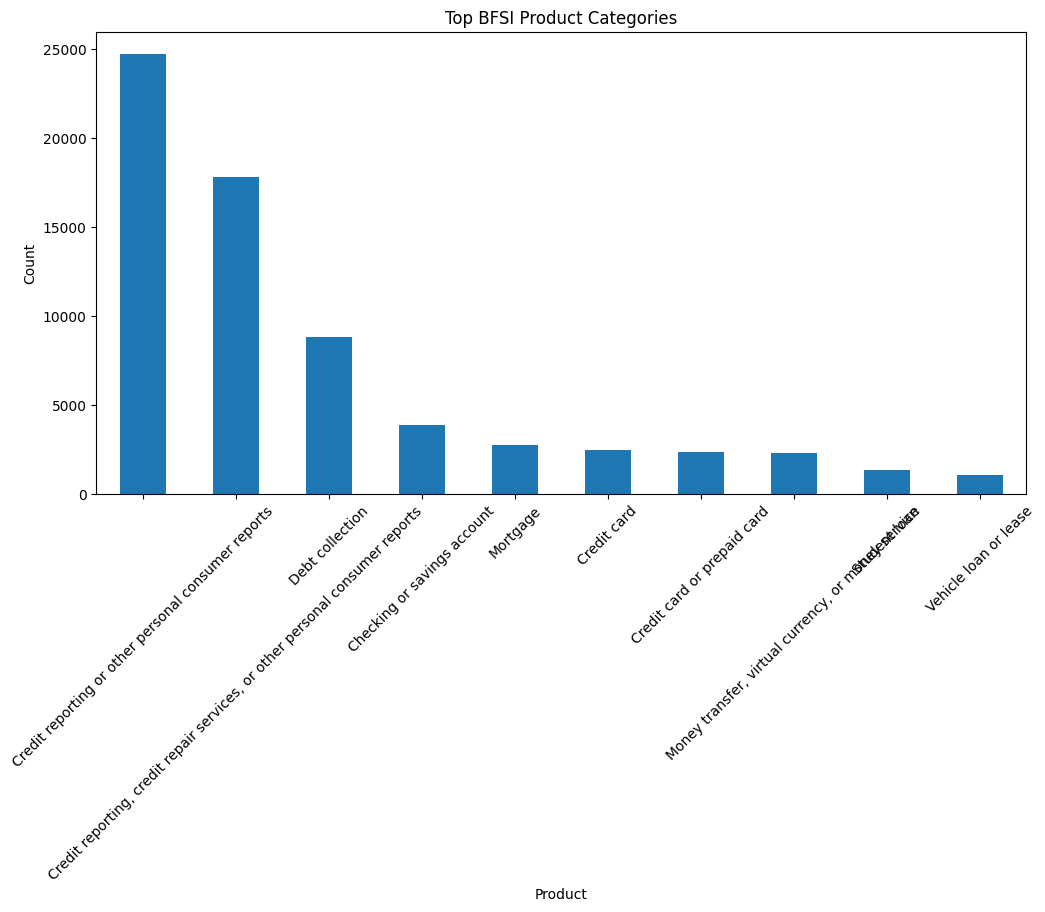


===== ISSUE DISTRIBUTION =====



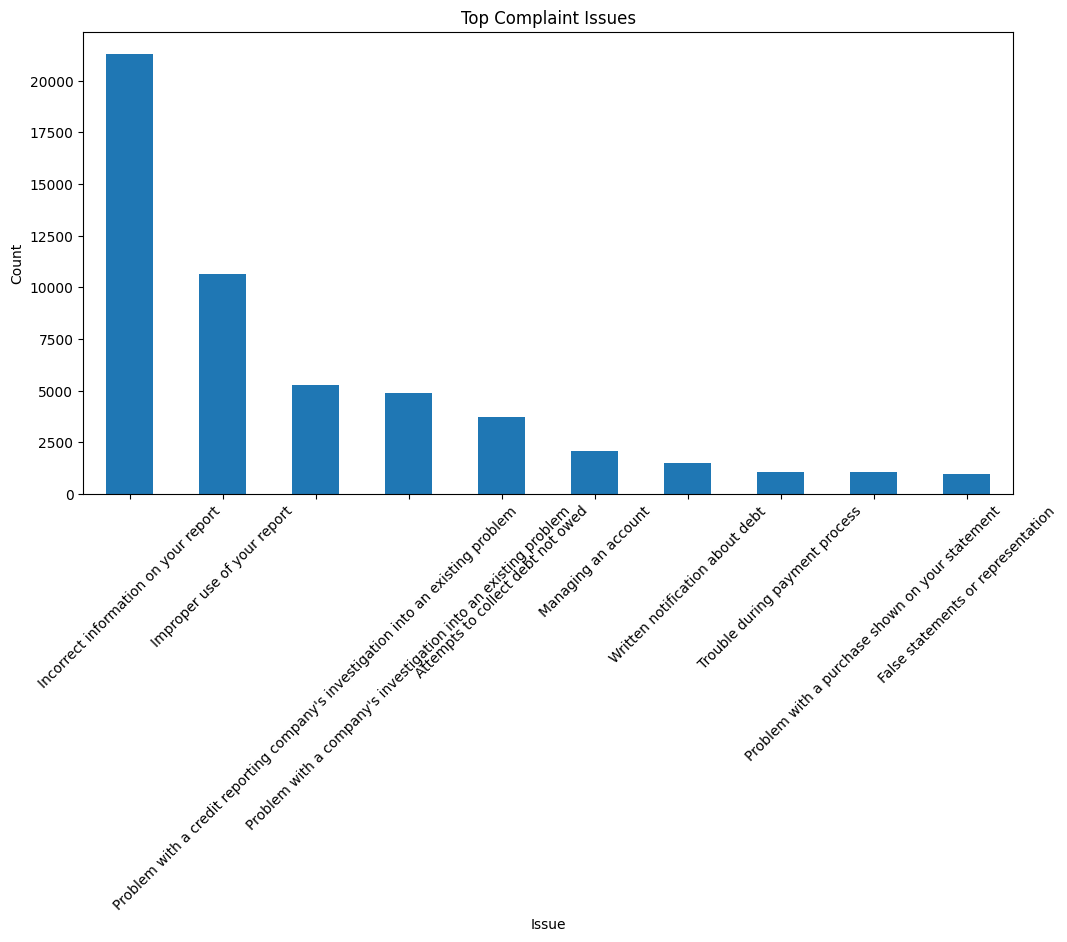

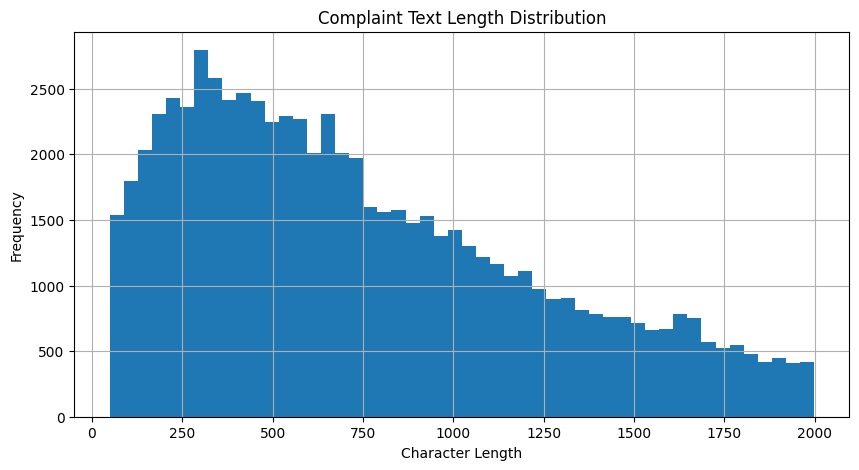


===== SAMPLE CLEANED RECORDS =====

                                               Product  \
0  Credit reporting or other personal consumer reports   
1  Credit reporting or other personal consumer reports   
2                                      Debt collection   

                                  Issue  \
0  Incorrect information on your report   
1  Incorrect information on your report   
2     Attempts to collect debt not owed   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [3]:
print("\n===== Importing Required Libraries =====\n")

# ================================================================
# 2. Importing Required Libraries
# ================================================================

# ================================================================
# 2.1 Core Python & Utility Libraries
# ================================================================

import os
import re
import random
import warnings

warnings.filterwarnings('ignore')

# ================================================================
# 2.2 Data Handling & Processing Libraries
# ================================================================

import pandas as pd
import numpy as np

# ================================================================
# 2.3 Progress Monitoring Libraries
# ================================================================

from tqdm import tqdm

# ================================================================
# RANDOM SEED FOR REPRODUCIBILITY
# ================================================================

random.seed(42)

np.random.seed(42)

# ================================================================
# 2.4 LIBRARY VERSIONS
# ================================================================

print("===== LIBRARY VERSIONS =====\n")

from importlib.metadata import (
    version,
    PackageNotFoundError
)

def get_version(pkg_name):

    try:
        return version(pkg_name)

    except PackageNotFoundError:
        return "Not installed"

    except Exception:
        return "Version not found"


# ================================================================
# PYTHON VERSION
# ================================================================

import platform

print("Python:", platform.python_version())


# ================================================================
# DATA LIBRARIES
# ================================================================

print("pandas:", pd.__version__)

print("numpy:", np.__version__)


# ================================================================
# PROGRESS LIBRARY
# ================================================================

import tqdm

print("tqdm:", tqdm.__version__)


# ================================================================
# BUILT-IN
# ================================================================

print("re: built-in (no version)")

print("\n===== DATASET PREPARATION =====\n")

# ================================================================
# 3. Dataset Loading, Cleaning and Preparation for BFSI Tasks
#     URL → Download → Extract → Chunk Load → Clean → Final Dataset
# ================================================================

# The CFPB Consumer Complaint Dataset is used as the primary data source for this study.
# It contains real-world financial complaints submitted by customers across various BFSI domains
# such as credit cards, loans, mortgages, and banking services.

# Due to the large dataset size (~8GB), chunk-based loading is applied to efficiently read
# and process data without exceeding memory limits.

# The dataset includes multiple fields such as Product, Issue, Consumer complaint narrative,
# and Company response. The 'Consumer complaint narrative' field is the key input for Task 1
# (Risk Analysis Summarization), as it contains unstructured customer descriptions of issues.


print("===== Dataset Loading, Cleaning and Preparation for BFSI Tasks =====\n")

# Downloads compressed dataset from URL and saves it locally for processing
import urllib.request

# CFPB dataset URL (zip file)
url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

# Local path in Colab
zip_path = "/content/complaints.zip"

print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)
print("Download completed")

# Extracts the downloaded zip file to make the CSV dataset available for processing
import zipfile

extract_path = "/content/"

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")

# Checks if the extracted CSV file exists to ensure dataset is ready for processing
import os

csv_path = "/content/complaints.csv"

print("File exists:", os.path.exists(csv_path))

# Define required columns

required_columns = [
    'Consumer complaint narrative',
    'Product',
    'Issue',
    'Company response to consumer',
    'Date received'
]

# Loads large dataset in chunks, cleans it, and creates a fixed-size high-quality dataset

pd.set_option('display.max_colwidth', None)

# Required columns for BFSI thesis experiments
required_columns = [
    'Date received',
    'Product',
    'Issue',
    'Company response to consumer',
    'Consumer complaint narrative'
]

# Load dataset with selected columns only
def load_100k_required_columns(
    file_path,
    target_rows=100000,
    chunksize=100000
):

    collected_data = []
    total_collected = 0

    for chunk in pd.read_csv(
        file_path,
        chunksize=chunksize,
        usecols=required_columns
    ):

        # Remove rows with missing complaint narrative
        chunk = chunk.dropna(
            subset=['Consumer complaint narrative']
        )

        # Remove very short complaints
        chunk = chunk[
            chunk['Consumer complaint narrative'].str.len() > 50
        ]

        collected_data.append(chunk)

        total_collected += len(chunk)

        print(f"Collected: {total_collected}")

        # Stop after reaching target
        if total_collected >= target_rows:
            break

    # Combine all chunks
    final_df = pd.concat(collected_data)

    # Keep only required rows
    final_df = final_df.head(target_rows)

    # Reset index
    final_df = final_df.reset_index(drop=True)

    return final_df


# Load dataset
df = load_100k_required_columns(csv_path)

print("Final Shape:", df.shape)

print("\n===== DATASET INFORMATION =====\n")

print(df.info())

# ================================================================
# Data cleaning steps include:
# - Removing records with missing complaint narratives
# - Filtering out very short or low-information complaints
# - Removing duplicate entries to ensure data quality
# - Applying text normalization (lowercasing, whitespace cleanup)
# ================================================================
df = df.drop_duplicates(subset=['Consumer complaint narrative'])
print("After duplicate removal:", df.shape)

# Text Cleaning
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    text = text.strip()

    return text

# Apply text cleaning function to the 'Consumer complaint narrative' column
# to standardize the text (e.g., convert to lowercase, remove unnecessary spaces, etc.)
# and store the processed output in a new column called 'clean_text'

df['clean_text'] = df['Consumer complaint narrative'].apply(clean_text)

# Display original and cleaned text side-by-side for validation
# to ensure preprocessing has been applied correctly
df[['Consumer complaint narrative', 'clean_text']].head()

# Additional Filtering
# Removing extremely long complaints
df = df[df['clean_text'].str.len() < 2000]

# Remove rows with weird patterns (optional)
df = df[df['clean_text'].str.contains('[a-z]', regex=True)]

print("After quality filtering:", df.shape)

print("Start Feature Creation:", df.shape)
#Feature Creation
# Length feature
df['text_length'] = df['clean_text'].apply(len)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df[['text_length', 'word_count']].describe()


# ================================================================
# EXPORT FEATURE STATISTICS
# ================================================================

feature_stats = df[[
    'text_length',
    'word_count'
]].describe()

feature_stats.to_csv(
    "dataset_feature_statistics.csv"
)

# After preprocessing, a reduced dataset (~50K–100K records) is created.
# From this, a final sampled subset (~400 records) is selected for controlled experimentation
# across different prompt engineering strategies.

print(" Dataset Loading, Cleaning and Preparation Completed")


print("\n===== FINAL EXPERIMENT DATASET =====\n")

# Final dataset for experiments
final_df = df.sample(200, random_state=42).reset_index(drop=True)

print("Final experiment dataset:", final_df.shape)
final_df.head()

# ================================================================
# ADD RECORD ID COLUMN
# ================================================================

final_df['record_id'] = final_df.index

# ================================================================
# FINAL DATASET VALIDATION
# ================================================================

print("\n===== FINAL DATASET VALIDATION =====\n")

print(
    "Null values:",
    final_df.isnull().sum().sum()
)

print(
    "Duplicate rows:",
    final_df.duplicated().sum()
)

print(
    "Final Shape:",
    final_df.shape
)

# ================================================================
# 4 Data Visualization
# ================================================================

print("\n===== DATA VISUALIZATION =====\n")

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Plot histogram of word count distribution to understand the length
# variation of complaint narratives across the dataset
plt.figure(figsize=(10,5))

df['word_count'].hist(bins=50)

# Add title to the plot for clarity
plt.title("Word Count Distribution")

# Display the histogram
plt.show()

# ================================================================
# PRODUCT DISTRIBUTION
# ================================================================

print("\n===== PRODUCT DISTRIBUTION =====\n")

plt.figure(figsize=(12,6))

df['Product'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Top BFSI Product Categories"
)

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ================================================================
# ISSUE DISTRIBUTION
# ================================================================

print("\n===== ISSUE DISTRIBUTION =====\n")

plt.figure(figsize=(12,6))

df['Issue'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Top Complaint Issues"
)

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ================================================================
# TEXT LENGTH DISTRIBUTION
# ================================================================

plt.figure(figsize=(10,5))

df['text_length'].hist(
    bins=50
)

plt.title(
    "Complaint Text Length Distribution"
)

plt.xlabel("Character Length")

plt.ylabel("Frequency")

plt.show()

# ================================================================
# SAMPLE CLEANED RECORDS
# ================================================================

print("\n===== SAMPLE CLEANED RECORDS =====\n")

print(
    final_df[[
        'Product',
        'Issue',
        'clean_text'
    ]].head(3)
)

# ================================================================
# 5. EXPORT CLEANED BFSI DATASET
# ================================================================

print("\n===== EXPORTING CLEANED BFSI DATASET =====\n")


# ================================================================
# EXPORT TO CSV
# ================================================================

final_df.to_csv(

    "common_bfsi_dataset.csv",

    index=False
)

# ================================================================
# EXPORT TO EXCEL
# ================================================================

final_df.to_excel(

    "common_bfsi_dataset.xlsx",

    index=False
)

# ================================================================
# EXPORT CONFIRMATION
# ================================================================

print(
    "Dataset exported successfully"
)

print(
    "CSV File  : common_bfsi_dataset.csv"
)

print(
    "EXCEL File  : common_bfsi_dataset.xlsx"
)

print(
    "Total Records:",
    len(final_df)
)


print("\n===== DATASET PREPARATION COMPLETED SUCCESSFULLY =====\n")